# NutriWise — BLS-4.0 corpus EDA (the matching target)

**Purpose.** The BLS-4.0 food table is the *target side* of our matching problem — every
receipt line must map to one BLS entry. This notebook characterizes the corpus **only where
it informs matching**, not as a nutrient study.

Three questions:
1. How big and how unique is the candidate pool?
2. Do we have German *and* English names? (justifies a multilingual embedding)
3. How fine-grained are the entries? (this is *why* matching is hard — the "domain
   blindness" failure mode is baked into the corpus)

*Out of scope here:* distributions of kcal / protein / etc. — those belong to the product's
nutrition estimation, not to matching.

---
## Setup — paths, imports, house style

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "ml" else Path.cwd()
BLS_DATA = REPO / "BLS_data" / "BLS_4_0_Daten_2025_DE.xlsx"
BLS_COMP = REPO / "BLS_data" / "BLS_4_0_Components_DE_EN.xlsx"
for p in (BLS_DATA, BLS_COMP):
    assert p.exists(), f"Missing: {p}"

# NutriWise corporate design: one accent (sage green), whitespace, sans-serif
SAGE, SOFT, INK, INK_SOFT = "#7c9a6a", "#eef2ea", "#1d1d21", "#6e6f74"
plt.rcParams.update({"font.family": "sans-serif", "axes.edgecolor": INK_SOFT})

def hbar(labels, values, title, xlabel, highlight_max=True, fmt=None, figsize=(8, 4)):
    fig, ax = plt.subplots(figsize=figsize)
    top = max(values) if values else 0
    colors = [SAGE if (highlight_max and v == top) else SOFT for v in values]
    bars = ax.barh(labels, values, color=colors, edgecolor=SAGE, linewidth=1)
    pad = (max(values) if values else 1) * 0.01
    for bar, v in zip(bars, values):
        ax.text(v + pad, bar.get_y() + bar.get_height()/2,
                fmt(v) if fmt else f"{v:,}", va="center", ha="left",
                color=INK, fontsize=9)
    ax.set_xlabel(xlabel, color=INK_SOFT)
    ax.set_title(title, color=INK, pad=12, loc="left")
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.tick_params(colors=INK_SOFT)
    plt.tight_layout(); plt.show()

print("Setup OK.")

Setup OK.


---
## 1. Size, uniqueness, and language coverage

In [2]:
bls = pd.read_excel(BLS_DATA)
print(f"BLS table: {bls.shape[0]:,} rows x {bls.shape[1]} columns")

DE_COL, EN_COL = "Lebensmittelbezeichnung", "Food name"
de = bls[DE_COL].dropna().astype(str).str.strip()
en = bls[EN_COL].dropna().astype(str).str.strip()
print(f"German names : {(de != '').sum():,} non-empty | {de[de!=''].nunique():,} unique")
print(f"English names: {(en != '').sum():,} non-empty (=> multilingual matching is supported)")

meta_cols = {"BLS Code", DE_COL, EN_COL}
nutrient_cols = [c for c in bls.columns if c not in meta_cols]
print(f"Nutrient/meta data columns: {len(nutrient_cols)} "
      f"(available *after* a match — see section 3)")
bls[["BLS Code", DE_COL, EN_COL]].head(4)

BLS table: 7,140 rows x 418 columns
German names : 7,140 non-empty | 7,140 unique
English names: 7,140 non-empty (=> multilingual matching is supported)
Nutrient/meta data columns: 415 (available *after* a match — see section 3)


,BLS Code,Lebensmittelbezeichnung,Food name
0,C131000,"Hafer ganzes Korn, roh","Oat whole grain, raw"
1,C133000,Hafer Flocken,Oat flakes
2,C141000,"Gerste ganzes Korn, roh","Barley whole grain, raw"
3,C243000,Gerste Mehl,Barley flour


---
## 2. Name length — long, descriptive labels

BLS names are not short tokens; they are descriptive phrases. Long target names + short,
abbreviated receipt lines (`"CHILI MIX TRI."`) is exactly the gap the matcher must bridge.

name length (chars): mean 34.9 | median 32 | min 3 | max 132


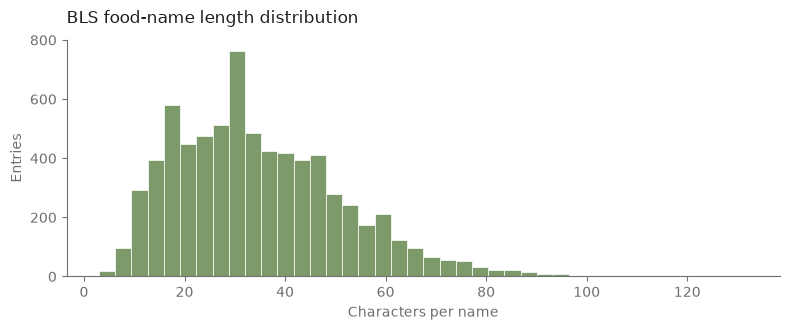

In [3]:
lengths = de.str.len()
print(f"name length (chars): mean {lengths.mean():.1f} | median {int(lengths.median())} "
      f"| min {lengths.min()} | max {lengths.max()}")

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(lengths, bins=40, color=SAGE, edgecolor="white", linewidth=0.5)
ax.set_title("BLS food-name length distribution", color=INK, pad=12, loc="left")
ax.set_xlabel("Characters per name", color=INK_SOFT)
ax.set_ylabel("Entries", color=INK_SOFT)
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.tick_params(colors=INK_SOFT)
plt.tight_layout(); plt.show()

---
## 3. Granularity = why matching is hard (domain blindness)

The corpus encodes **preparation state** (raw / cooked / fried / steamed …) and **fat
levels** as separate entries. So a single real-world item ("potato") maps to *many*
near-identical BLS candidates that differ only in a nuance an off-the-shelf embedding does
not understand. This is the concrete, corpus-level reason our finding holds: **embeddings
are a tie-breaker, not the main matcher.**

Entries carrying a fat/percentage marker (e.g. '3,5 %'): 377


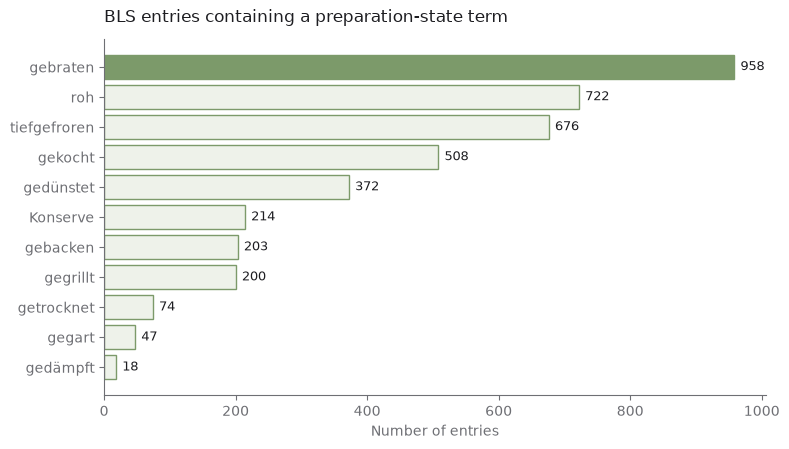

In [4]:
prep_terms = ["roh", "gekocht", "gebraten", "gedünstet", "gegrillt", "gebacken",
              "tiefgefroren", "Konserve", "getrocknet", "gegart", "gedämpft"]
counts = {t: int(de.str.contains(t, case=False, regex=False).sum()) for t in prep_terms}
counts = dict(sorted(counts.items(), key=lambda kv: kv[1]))
pct_marker = int(de.str.contains(r"\d+\s*%", regex=True).sum())
print(f"Entries carrying a fat/percentage marker (e.g. '3,5 %'): {pct_marker}")
hbar(list(counts.keys()), list(counts.values()),
     "BLS entries containing a preparation-state term",
     "Number of entries", fmt=lambda v: f"{int(v)}", figsize=(8, 4.6))

In [5]:
# A single everyday item -> many near-identical candidates
print("Example candidate family for 'Kartoffel' (potato):\n")
for x in de[de.str.contains("Kartoffel", case=False)].head(12):
    print("  -", x)

Example candidate family for 'Kartoffel' (potato):

  - Kartoffelstärke (Kartoffelmehl)
  - Kartoffelpüree Instantpulver
  - Kartoffelkloß (aus rohen Kartoffeln) Trockenprodukt
  - Kartoffelkloß (aus gekochten Kartoffeln) Trockenprodukt
  - Kartoffel geschält, roh
  - Kartoffelchips/Stapelchips, diverse Sorten
  - Batate/Süßkartoffel, roh
  - Kartoffel ungeschält, roh
  - Kartoffelchips energiereduziert
  - Kartoffelsticks
  - Kartoffelpuffer/Reibekuchen (mit saurer Sahne und Grieß) gebraten
  - Süßkartoffeln gedünstet (mit Fett und Salz)


---
## 4. Component dictionary (context, not matching)

`BLS_4_0_Components_DE_EN.xlsx` documents what each nutrient column means. Relevant later:
once a receipt line is matched, all these values come "for free" for kcal/nutrition
estimation. Not used for matching.

In [6]:
comp = pd.read_excel(BLS_COMP, sheet_name=0)
print(f"Component definitions: {len(comp)} "
      f"(e.g. energy, protein, fat, vitamins ...)")
comp[[c for c in comp.columns if "name" in c.lower() or "group" in c.lower()]].head(5)

Component definitions: 145 (e.g. energy, protein, fat, vitamins ...)


,Component name,Component group
0,Energy (kilojoule),Energy
1,Energy (kilocalorie),Energy
2,Water,Proximate composition
3,Protein (Nx6.25),Proximate composition
4,Fat,Proximate composition


---
## Summary — what this means for matching

- **Candidate pool:** 7,140 unique BLS names — a genuine needle-in-a-haystack retrieval.
- **Bilingual:** German *and* English names present → a multilingual embedding is a sound
  choice (not a workaround).
- **Fine granularity is the core difficulty:** thousands of entries differ only by
  preparation state or fat level. One everyday item → many near-identical candidates. This
  is the corpus-level root cause of the "domain blindness" errors and confirms the honest
  message: **use embeddings as a tie-breaker, fuzzy for the shortlist.**
- **Nutrition is downstream:** 415 nutrient columns exist but are irrelevant to matching;
  they pay off *after* a correct match.

Together with `data_eda.ipynb` (the query side), this completes the picture: short,
abbreviated receipt lines on one side; long, finely-graded BLS names on the other — which
is exactly why a labeled gold-set and an honest evaluation matter.